In [2]:
import sys
import os 

In [3]:
sys.path.append("../src")

In [4]:
from data_load import load_matches
from data_preprocess import extract_deliveries

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
data_path = "../data/raw_matches"
matches = load_matches(data_path)
print("Matches loaded:", len(matches))


Matches loaded: 1169


In [7]:
df = extract_deliveries(matches)
df.head()
# print(type(df))

,match_id,date,team1,team2,venue,over,batter,bowler,runs_batter,runs_total,is_wicket,dismissal_kind,player_out
0,0,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,"Rajiv Gandhi International Stadium, Uppal",0,DA Warner,TS Mills,0,0,0,NaN,NaN
1,0,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,"Rajiv Gandhi International Stadium, Uppal",0,DA Warner,TS Mills,0,0,0,NaN,NaN
2,0,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,"Rajiv Gandhi International Stadium, Uppal",0,DA Warner,TS Mills,4,4,0,NaN,NaN
3,0,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,"Rajiv Gandhi International Stadium, Uppal",0,DA Warner,TS Mills,0,0,0,NaN,NaN
4,0,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,"Rajiv Gandhi International Stadium, Uppal",0,DA Warner,TS Mills,0,2,0,NaN,NaN


In [8]:
rohit_df = df[df["batter"] == "RG Sharma"]
# print(rohit_df)

In [9]:

total_runs = rohit_df["runs_batter"].sum()
balls = len(rohit_df)

strike_rate = (total_runs/balls) * 100

print("Runs:", total_runs)
print("Balls:", balls)
print("Strike Rate:", strike_rate)

Runs: 7048
Balls: 5475
Strike Rate: 128.73059360730593


In [10]:
def phase(over):
    if over <= 6:
        return "Powerplay"
    elif over <=15:
        return "Middle"
    else:
        return "Death"
    
rohit_df["phase"] = rohit_df["over"].apply(phase)

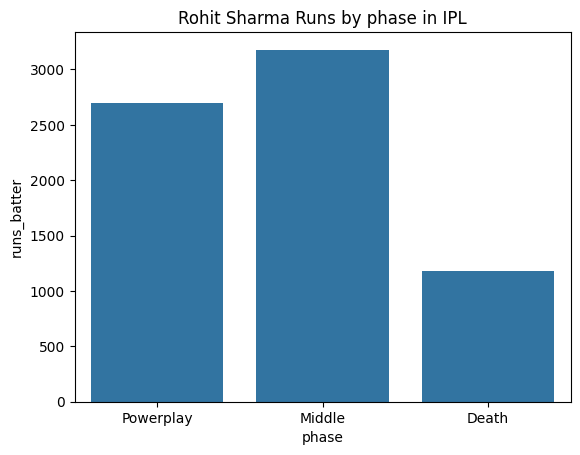

In [11]:
phase_runs = rohit_df.groupby("phase")["runs_batter"].sum()
phase_runs = phase_runs.reset_index()
phase_order = ["Powerplay", "Middle", "Death"]
# print(type(phase_runs))
sns.barplot(
    x="phase", 
    y="runs_batter", 
    data=phase_runs, 
    order=phase_order
    )

plt.title("Rohit Sharma Runs by phase in IPL")
plt.savefig("../charts/phase_runs.png")
plt.show()

Rohit Sharma scores higher runs in the middle overs, suggesting a role that beyond aggresive starts into building innings stability. 

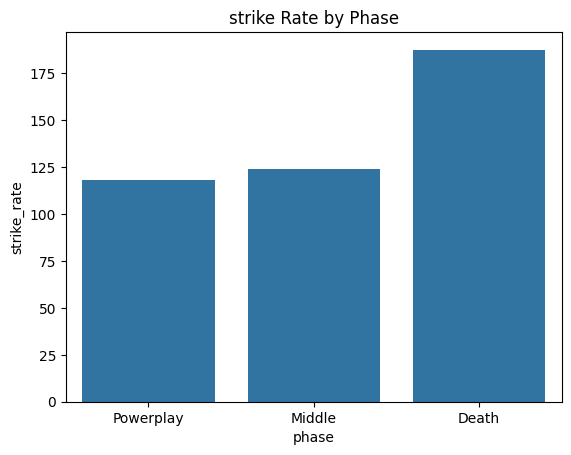

In [14]:
phase_stats = rohit_df.groupby("phase").agg({"runs_batter": "sum","batter": "count"})
phase_order = ["Powerplay", "Middle", "Death"]
phase_stats["strike_rate"] = (phase_stats["runs_batter"] / phase_stats["batter"])*100
sns.barplot(x="phase", y="strike_rate", data=phase_stats, order=phase_order)

plt.title("strike Rate by Phase")
plt.savefig("../charts/strike_rate_phase.png")
plt.show()

Strike rate is highest in Death overs but drops in Powerplay and Middle overs, indicating a slower scoring phase.

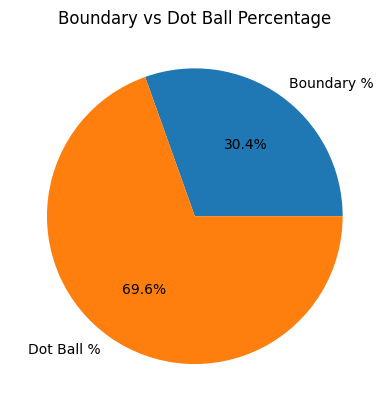

In [15]:
rohit_df["is_boundary"] = rohit_df["runs_batter"].isin([4,6])
rohit_df["is_dot"] = rohit_df["runs_batter"] == 0

boundary_pct = rohit_df["is_boundary"].mean() * 100
dot_pct = rohit_df["is_dot"].mean() * 100

labels = ["Boundary %", "Dot Ball %"]
values = [boundary_pct, dot_pct]

plt.pie(values, labels=labels, autopct= "%1.1f%%")
plt.title("Boundary vs Dot Ball Percentage")

plt.savefig("../charts/boundary_dot.png")
plt.show()

Rohit has a good boundary percentage but also a noticeable number of dot balls, showing phases of pressure.

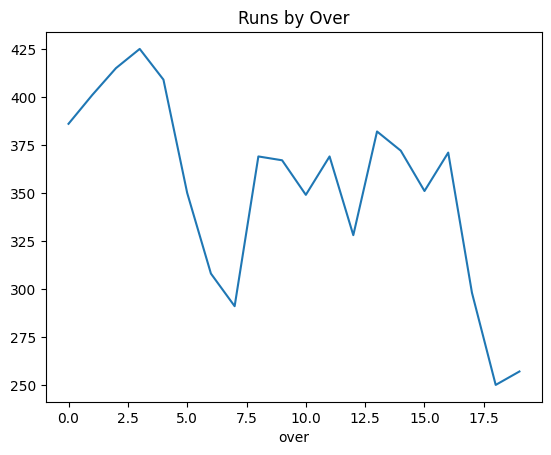

In [16]:
runs_by_over = rohit_df.groupby("over")["runs_batter"].sum()

sns.lineplot(x=runs_by_over.index, y=runs_by_over.values)

plt.title("Runs by Over")
plt.savefig("../charts/runs_by_over.png")
plt.show()

Runs are higher in early overs, slow down in middle overs, and increase again towards the end.

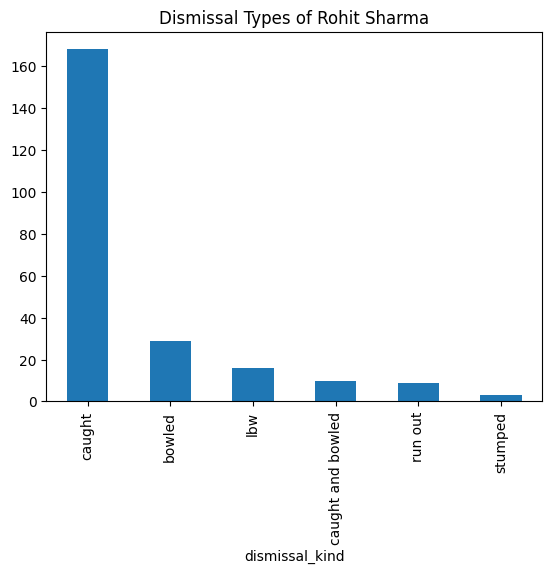

In [17]:
dismissals = rohit_df[
    (rohit_df["player_out"] == "RG Sharma")
]

dismissal_counts = dismissals["dismissal_kind"].value_counts()

dismissal_counts.plot(kind="bar")

plt.title("Dismissal Types of Rohit Sharma")
plt.savefig("../charts/dismissal_types.png")
plt.show()

Most dismissals are catches, indicating aggressive shot selection and risk-taking.

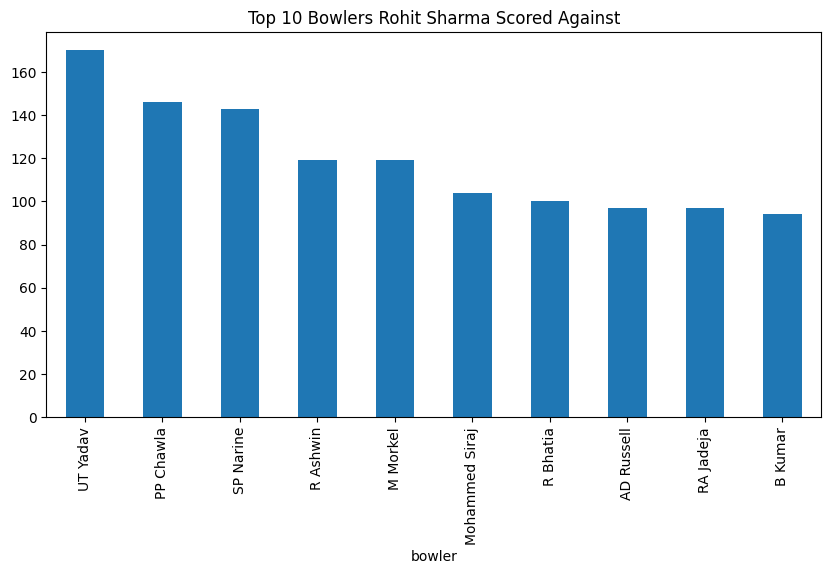

In [18]:
runs_vs_bowler = rohit_df.groupby("bowler")["runs_batter"].sum().sort_values(ascending=False).head(10)

runs_vs_bowler.plot(kind="bar", figsize=(10,5))

plt.title("Top 10 Bowlers Rohit Sharma Scored Against")
plt.savefig("../charts/runs_vs_bowler.png")
plt.show()

Rohit has faced some bowlers frequently, which can help analyze specific matchups.

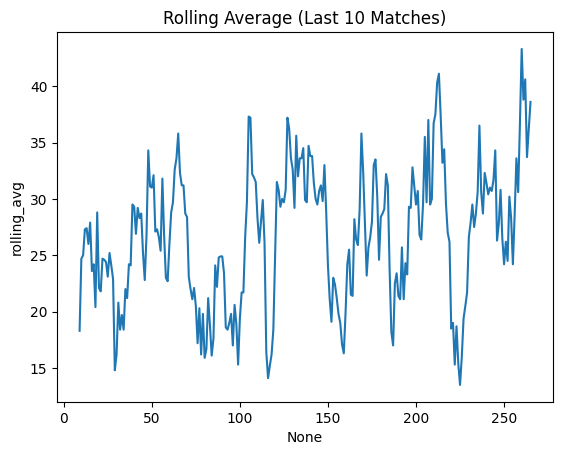

In [25]:
match_runs = rohit_df.groupby("match_id")["runs_batter"].sum().reset_index()

match_runs["rolling_avg"] = match_runs["runs_batter"].rolling(10).mean()

sns.lineplot(x=match_runs.index, y=match_runs["rolling_avg"])

plt.title("Rolling Average (Last 10 Matches)")
plt.savefig("../charts/rolling_avg.png")
plt.show()

The rolling average shows periods of good form followed by dips, indicating streak-based performance.

In [28]:
rohit_df = df[df["batter"] == "RG Sharma"].copy()

# Features
rohit_df["phase"] = rohit_df["over"].apply(lambda x: "Powerplay" if x<=6 else "Middle" if x<=15 else "Death")
rohit_df["is_boundary"] = rohit_df["runs_batter"].isin([4,6])
rohit_df["is_dot"] = rohit_df["runs_batter"] == 0
rohit_df["year"] = pd.to_datetime(rohit_df["date"]).dt.year
rohit_df["is_out"] = rohit_df["player_out"] == "RG Sharma"

print("Final columns:", rohit_df.columns)

Final columns: Index(['match_id', 'date', 'team1', 'team2', 'venue', 'over', 'batter',
       'bowler', 'runs_batter', 'runs_total', 'is_wicket', 'dismissal_kind',
       'player_out', 'phase', 'is_boundary', 'is_dot', 'year', 'is_out'],
      dtype='str')


In [20]:
final_df = rohit_df[[
    "match_id",
    "date",
    "year",
    "venue",
    "team1",
    "team2",
    "over",
    "phase",
    "bowler",
    "runs_batter",
    "runs_total",
    "is_boundary",
    "is_dot",
    "is_wicket",
    "dismissal_kind",
    "is_out"
]]

In [21]:
final_df.to_csv("../data/processed/rohit_ipl.csv", index=False)